## Version 1 — Transformer (4-layer encoder, d_model=256)

6-class gesture recognition with a Transformer encoder on MediaPipe hand landmarks `(37, 63)`.

Input projection `63 → 256`, 4 encoder layers, single-head attention pooling → classifier.

Classes: No gesture, Swiping Left/Right, Turning Hand Clockwise/Counterclockwise, Zooming In With Two Fingers.

In [31]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Left",
    "Swiping Right",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

VERSION_DIR = ROOT / "version1"
MODELS_DIR = VERSION_DIR / "models"

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
NUM_LAYERS = 4
DROPOUT = 0.3
D_MODEL = 256
NHEAD = 4
DIM_FEEDFORWARD = 512
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MIN_LR = 1e-6
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")
print(f"Classes ({NUM_CLASSES}): {LABELS}")

Device: mps
Classes (6): ['No gesture', 'Swiping Left', 'Swiping Right', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Two Fingers']


## Dataset

In [32]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            label = row["label"]
            if label not in LABEL_TO_IDX:
                continue

            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue

            self.samples.append((npy_path, LABEL_TO_IDX[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

print("\nTrain label distribution:")
train_labels = pd.Series([IDX_TO_LABEL[label] for _, label in train_dataset.samples])
print(train_labels.value_counts())

Train: 12782
Val:   1616
Test:  1595

Train label distribution:
No gesture                       5749
Zooming In With Two Fingers      1646
Swiping Left                     1464
Swiping Right                    1447
Turning Hand Counterclockwise    1258
Turning Hand Clockwise           1218
Name: count, dtype: int64


## Transformer model

In [33]:
class AttentionPooling(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attention = nn.Linear(d_model, 1)

    def forward(self, x):
        weights = torch.softmax(self.attention(x), dim=1)
        return (x * weights).sum(dim=1)


class GestureTransformer(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
        max_len=NUM_FRAMES,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        self.attn_pool = AttentionPooling(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embedding[:, : x.size(1), :]
        x = self.transformer(x)
        pooled = self.attn_pool(x)
        logits = self.classifier(self.dropout(pooled))
        return logits


model = GestureTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
    eta_min=MIN_LR,
)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(
    f"LR schedule: CosineAnnealingLR "
    f"({LEARNING_RATE:.0e} -> {MIN_LR:.0e} over {MAX_EPOCHS} epochs)"
)
print(model)

Trainable parameters: 543,751
LR schedule: CosineAnnealingLR (1e-03 -> 1e-06 over 50 epochs)
GestureTransformer(
  (input_proj): Linear(in_features=63, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (attn_pool): AttentionPooling(
    (attention): Linear(in_features=128, out_features=1

## Training (cosine annealing LR + early stopping on validation loss)

In [34]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr": [],
}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | lr {current_lr:.2e} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | lr 1.00e-03 | train loss 0.9572 acc 0.6281 | val loss 0.7069 acc 0.7259
Epoch 02 | lr 9.99e-04 | train loss 0.6313 acc 0.7701 | val loss 0.5567 acc 0.8298
Epoch 03 | lr 9.96e-04 | train loss 0.4748 acc 0.8526 | val loss 0.5095 acc 0.8416
Epoch 04 | lr 9.91e-04 | train loss 0.4455 acc 0.8644 | val loss 0.4923 acc 0.8410
Epoch 05 | lr 9.84e-04 | train loss 0.4255 acc 0.8713 | val loss 0.5099 acc 0.8509
Epoch 06 | lr 9.76e-04 | train loss 0.4090 acc 0.8776 | val loss 0.5359 acc 0.8379
Epoch 07 | lr 9.65e-04 | train loss 0.4046 acc 0.8788 | val loss 0.4701 acc 0.8589
Epoch 08 | lr 9.52e-04 | train loss 0.3936 acc 0.8833 | val loss 0.4469 acc 0.8614
Epoch 09 | lr 9.38e-04 | train loss 0.3742 acc 0.8873 | val loss 0.3994 acc 0.8775
Epoch 10 | lr 9.22e-04 | train loss 0.3684 acc 0.8873 | val loss 0.4757 acc 0.8626
Epoch 11 | lr 9.05e-04 | train loss 0.3676 acc 0.8893 | val loss 0.4257 acc 0.8725
Epoch 12 | lr 8.85e-04 | train loss 0.3634 acc 0.8889 | val loss 0.4805 acc 0.8620
Epoc

## Training curves

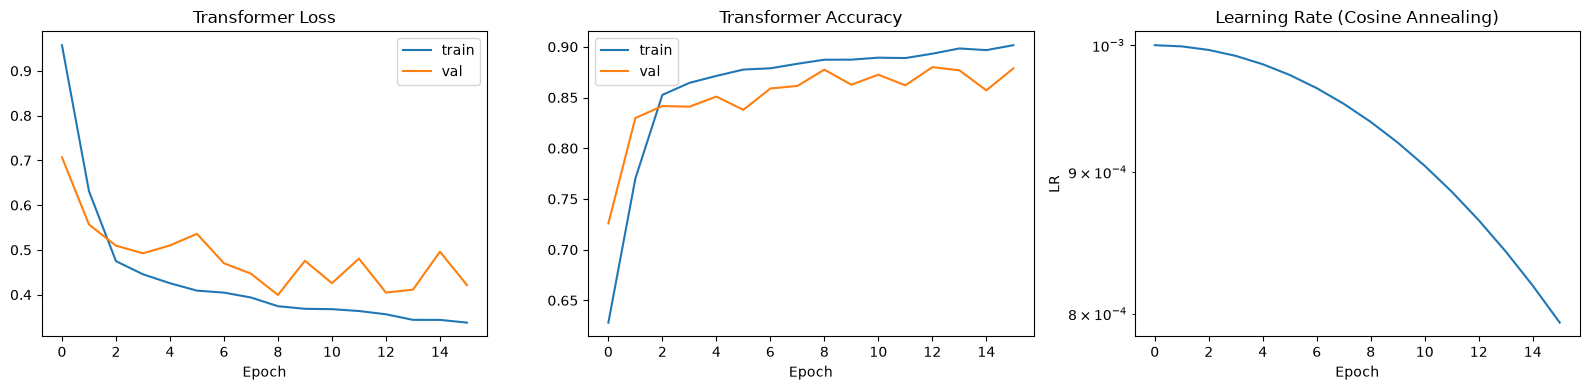

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Transformer Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Transformer Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["lr"])
axes[2].set_title("Learning Rate (Cosine Annealing)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 0.3334
Test accuracy: 0.8940

Classification report:
                               precision    recall  f1-score   support

                   No gesture     0.9084    0.9652    0.9359       719
                 Swiping Left     0.9153    0.8852    0.9000       183
                Swiping Right     0.8634    0.8927    0.8778       177
       Turning Hand Clockwise     0.8814    0.6797    0.7675       153
Turning Hand Counterclockwise     0.7630    0.8408    0.8000       157
  Zooming In With Two Fingers     0.9778    0.8544    0.9119       206

                     accuracy                         0.8940      1595
                    macro avg     0.8849    0.8530    0.8655      1595
                 weighted avg     0.8962    0.8940    0.8927      1595



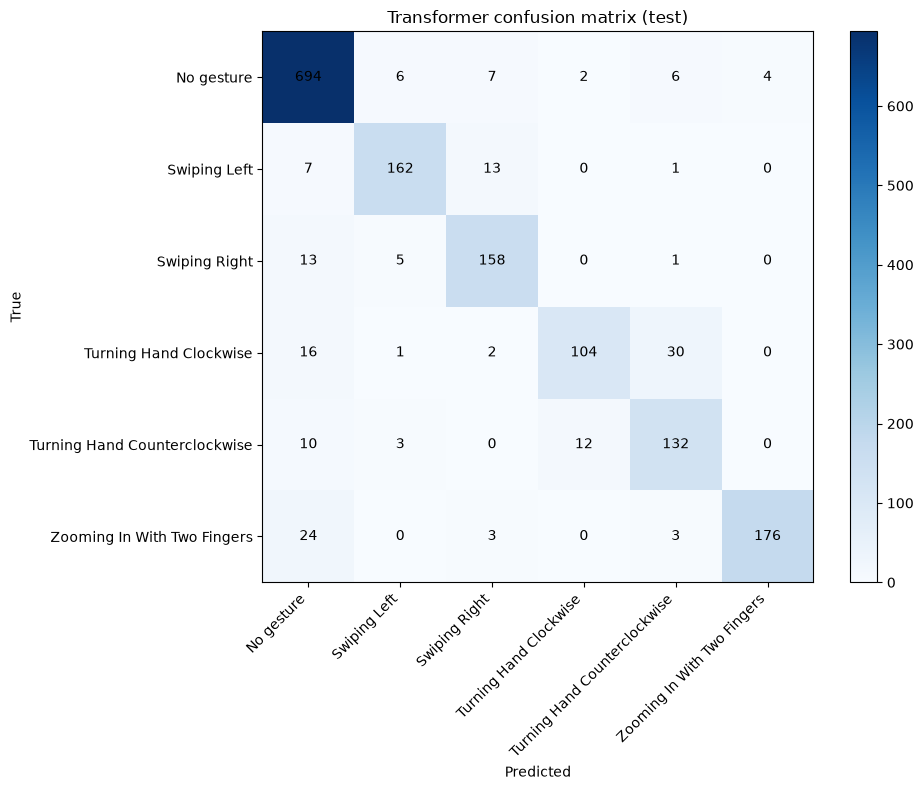

In [36]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Transformer confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save model

if "MODELS_DIR" not in globals():
    from pathlib import Path

    _root = Path.cwd()
    if not (_root / "version1").exists() and (_root.parent / "version1").exists():
        _root = _root.parent
    MODELS_DIR = _root / "version1" / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "GestureTransformer",
    "labels": LABELS,
    "label_to_idx": LABEL_TO_IDX,
    "hyperparameters": {
        "input_size": INPUT_SIZE,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "num_classes": NUM_CLASSES,
        "dropout": DROPOUT,
        "num_frames": NUM_FRAMES,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "min_lr": MIN_LR,
        "lr_scheduler": "CosineAnnealingLR",
        "seed": SEED,
    },
    "history": history,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
}

save_path = MODELS_DIR / "gesture_transformer_v1.pt"
torch.save(checkpoint, save_path)
print(f"Saved model to {save_path.resolve()}")